In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import os 

## Dataset Variables Description

The dataset contains several categories of variables describing the condition and behavior of hard drives.

- **Date (`date`)**  
  Indicates the day on which SMART data were collected.  
  It allows observations to be ordered chronologically, enabling time series analysis and monitoring of drive evolution over time.

- **Identifier (`serial_number`)**  
  Represents the unique serial number of each hard drive.  
  This variable is used to track the same drive across multiple days and group observations by hardware unit.

- **Model (`model`)**  
  Specifies the manufacturer reference or model of the hard drive.  
  It is useful for comparing reliability and failure patterns across different drive models.

- **Capacity (`capacity_bytes`)**  
  Represents the total storage capacity of the drive in bytes.  
  This variable can be used to study the relationship between storage size, performance, and durability.

- **Failure Indicator (`failure`)**  
  A binary target variable representing the state of the drive:
  
  - `0` → Healthy drive  
  - `1` → Failed drive  

  This variable is primarily used for supervised machine learning tasks.

- **SMART Attributes (`smart_*`)**  
  A collection of internal monitoring indicators related to hard drive health and behavior, including:
  
  - Error rates  
  - Temperature measurements  
  - Mechanical instabilities  
  - Read/write issues  
  - Operational delays  

  These attributes are the main predictive features used for failure analysis and predictive maintenance.

In [2]:
def load__data(train_path):
    files = os.listdir(train_path)
    dataframes = []
    for file in files:
        if file.endswith('.csv'):
            df = pd.read_csv(os.path.join(train_path, file))

            # Removing columns containing 'normilized' in their name
            drop_cols = []
            for col in df.columns:
                if 'normalized' in col.lower():
                    drop_cols.append(col)
            df.drop(columns=drop_cols, inplace=True)

            dataframes.append(df)
    return pd.concat(dataframes, ignore_index=True, sort=False)

## Q3 - 2016 S.M.A.R.T Data

In [3]:
train_path = 'D:/stochastic/data/data_Q4_2016'
train_df = load__data(train_path)

### Initial Inspection

In [4]:
train_df.head()

,date,serial_number,model,capacity_bytes,failure,smart_1_raw,smart_2_raw,smart_3_raw,smart_4_raw,smart_5_raw,...,smart_225_raw,smart_226_raw,smart_240_raw,smart_241_raw,smart_242_raw,smart_250_raw,smart_251_raw,smart_252_raw,smart_254_raw,smart_255_raw
0,2016-10-01,MJ0351YNG9Z0XA,Hitachi HDS5C3030ALA630,3000592982016,0,0.0,108.0,554.0,15.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-10-01,MJ0351YNG9WJSA,Hitachi HDS5C3030ALA630,3000592982016,0,0.0,104.0,555.0,20.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2016-10-01,PL1321LAG34XWH,Hitachi HDS5C4040ALE630,4000787030016,0,0.0,101.0,560.0,30.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2016-10-01,MJ0351YNGABYAA,Hitachi HDS5C3030ALA630,3000592982016,0,0.0,104.0,507.0,16.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2016-10-01,Z305B2QN,ST4000DM000,4000787030016,0,209710648.0,NaN,0.0,5.0,0.0,...,NaN,NaN,6739.0,2.718428e+10,5.928789e+09,NaN,NaN,NaN,NaN,NaN


In [5]:
train_df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 6589448 entries, 0 to 6589447
Data columns (total 50 columns):
 #   Column          Dtype  
---  ------          -----  
 0   date            str    
 1   serial_number   str    
 2   model           str    
 3   capacity_bytes  int64  
 4   failure         int64  
 5   smart_1_raw     float64
 6   smart_2_raw     float64
 7   smart_3_raw     float64
 8   smart_4_raw     float64
 9   smart_5_raw     float64
 10  smart_7_raw     float64
 11  smart_8_raw     float64
 12  smart_9_raw     float64
 13  smart_10_raw    float64
 14  smart_11_raw    float64
 15  smart_12_raw    float64
 16  smart_13_raw    float64
 17  smart_15_raw    float64
 18  smart_22_raw    float64
 19  smart_183_raw   float64
 20  smart_184_raw   float64
 21  smart_187_raw   float64
 22  smart_188_raw   float64
 23  smart_189_raw   float64
 24  smart_190_raw   float64
 25  smart_191_raw   float64
 26  smart_192_raw   float64
 27  smart_193_raw   float64
 28  smart_194_raw   float64

In [6]:
train_df.describe()

,capacity_bytes,failure,smart_1_raw,smart_2_raw,smart_3_raw,smart_4_raw,smart_5_raw,smart_7_raw,smart_8_raw,smart_9_raw,...,smart_225_raw,smart_226_raw,smart_240_raw,smart_241_raw,smart_242_raw,smart_250_raw,smart_251_raw,smart_252_raw,smart_254_raw,smart_255_raw
count,6.589448e+06,6.589448e+06,6.589447e+06,2.326019e+06,6.589447e+06,6.589447e+06,6.589447e+06,6.589447e+06,2.326019e+06,6.589447e+06,...,7.391600e+04,24387.000000,4.096201e+06,4.064546e+06,4.064546e+06,8.630000e+02,863.000000,863.0,9865.0,0.0
mean,4.301728e+12,5.296347e-05,7.493558e+07,9.083649e+01,3.286198e+02,1.188461e+01,2.137539e+00,1.509260e+10,3.602601e+01,1.624094e+04,...,1.958957e+05,335.615738,1.441566e+13,2.611422e+10,7.807085e+10,7.520498e+06,28088.436848,0.0,0.0,NaN
std,1.426980e+12,7.277408e-03,8.101446e+07,3.262937e+01,1.077663e+03,1.595243e+02,2.022938e+02,1.712759e+12,1.331457e+01,1.113655e+04,...,1.637746e+05,56.181017,4.993232e+13,9.037547e+09,4.657431e+11,6.856236e+06,21462.978134,0.0,0.0,NaN
min,1.600419e+11,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00,...,1.028600e+04,238.000000,0.000000e+00,9.002000e+03,9.889000e+03,2.457300e+04,87.000000,0.0,0.0,NaN
25%,4.000787e+12,0.000000e+00,0.000000e+00,1.000000e+02,0.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,3.700000e+01,7.017000e+03,...,7.354850e+04,267.000000,7.416000e+03,2.194819e+10,7.833672e+09,2.379770e+06,11701.000000,0.0,0.0,NaN
50%,4.000787e+12,0.000000e+00,4.610654e+07,1.020000e+02,0.000000e+00,6.000000e+00,0.000000e+00,3.201091e+08,4.200000e+01,1.431700e+04,...,1.224900e+05,373.000000,1.158400e+04,2.699862e+10,1.548769e+10,5.971426e+06,22916.000000,0.0,0.0,NaN
75%,4.000787e+12,0.000000e+00,1.439663e+08,1.040000e+02,4.460000e+02,1.300000e+01,0.000000e+00,5.305877e+08,4.200000e+01,2.301100e+04,...,2.846602e+05,382.000000,2.408600e+04,3.174389e+10,1.337588e+11,1.053834e+07,38737.000000,0.0,0.0,NaN
max,8.001563e+12,1.000000e+00,2.688171e+09,2.110000e+02,9.741000e+03,7.723700e+04,6.524800e+04,2.814715e+14,9.100000e+01,6.579700e+04,...,1.323800e+06,419.000000,2.814707e+14,6.788094e+10,3.233258e+13,3.192526e+07,98085.000000,0.0,0.0,NaN


### Detecting and removing constant columns

In [9]:
def remove_constant_columns(df, keyword=None):

    if keyword:
        selected_cols = [
            col for col in df.columns
            if keyword.lower() in col.lower()
        ]

        work_df = df[selected_cols]

    else:
        work_df = df.copy()

    indicators = pd.DataFrame({
        'distinct_values': work_df.nunique(),
        'min_value': work_df.min(),
        'max_value': work_df.max()
    })

    constant_columns = indicators[
        (indicators['distinct_values'] == 1) |
        (indicators['min_value'] == indicators['max_value'])
    ].index.tolist()

    cleaned_df = work_df.drop(columns=constant_columns)

    informative_columns = df.columns.difference(constant_columns)

    return indicators, constant_columns, informative_columns, cleaned_df

In [10]:
indicators, constant_columns, informative_columns, cleaned_df = remove_constant_columns(train_df)

In [11]:
print('shape before removing constant columns:', train_df.shape)
print('shape after removing constant columns:', cleaned_df.shape)

shape before removing constant columns: (6589448, 50)
shape after removing constant columns: (6589448, 45)


In [12]:
indicators

,distinct_values,min_value,max_value
date,92,2016-10-01,2016-12-31
serial_number,74453,13H2B97AS,ZA1440K7
model,59,HGST HDS5C4040ALE630,WDC WD60EFRX
capacity_bytes,13,160041885696,8001563222016
failure,2,0,1
smart_1_raw,3839563,0.0,2688171481.0
smart_2_raw,86,0.0,211.0
smart_3_raw,1427,0.0,9741.0
smart_4_raw,391,1.0,77237.0
smart_5_raw,614,0.0,65248.0


In [13]:
constant_columns

['smart_22_raw',
 'smart_220_raw',
 'smart_224_raw',
 'smart_252_raw',
 'smart_254_raw']

In [14]:
train_df[constant_columns].head()

,smart_22_raw,smart_220_raw,smart_224_raw,smart_252_raw,smart_254_raw
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN


In [15]:
train_df[constant_columns].isna().sum()

smart_22_raw     6585308
smart_220_raw    6565061
smart_224_raw    6565061
smart_252_raw    6588585
smart_254_raw    6579583
dtype: int64

In [16]:
informative_columns

Index(['capacity_bytes', 'date', 'failure', 'model', 'serial_number',
       'smart_10_raw', 'smart_11_raw', 'smart_12_raw', 'smart_13_raw',
       'smart_15_raw', 'smart_183_raw', 'smart_184_raw', 'smart_187_raw',
       'smart_188_raw', 'smart_189_raw', 'smart_190_raw', 'smart_191_raw',
       'smart_192_raw', 'smart_193_raw', 'smart_194_raw', 'smart_195_raw',
       'smart_196_raw', 'smart_197_raw', 'smart_198_raw', 'smart_199_raw',
       'smart_1_raw', 'smart_200_raw', 'smart_201_raw', 'smart_222_raw',
       'smart_223_raw', 'smart_225_raw', 'smart_226_raw', 'smart_240_raw',
       'smart_241_raw', 'smart_242_raw', 'smart_250_raw', 'smart_251_raw',
       'smart_255_raw', 'smart_2_raw', 'smart_3_raw', 'smart_4_raw',
       'smart_5_raw', 'smart_7_raw', 'smart_8_raw', 'smart_9_raw'],
      dtype='str')

### Removing Columns with null values

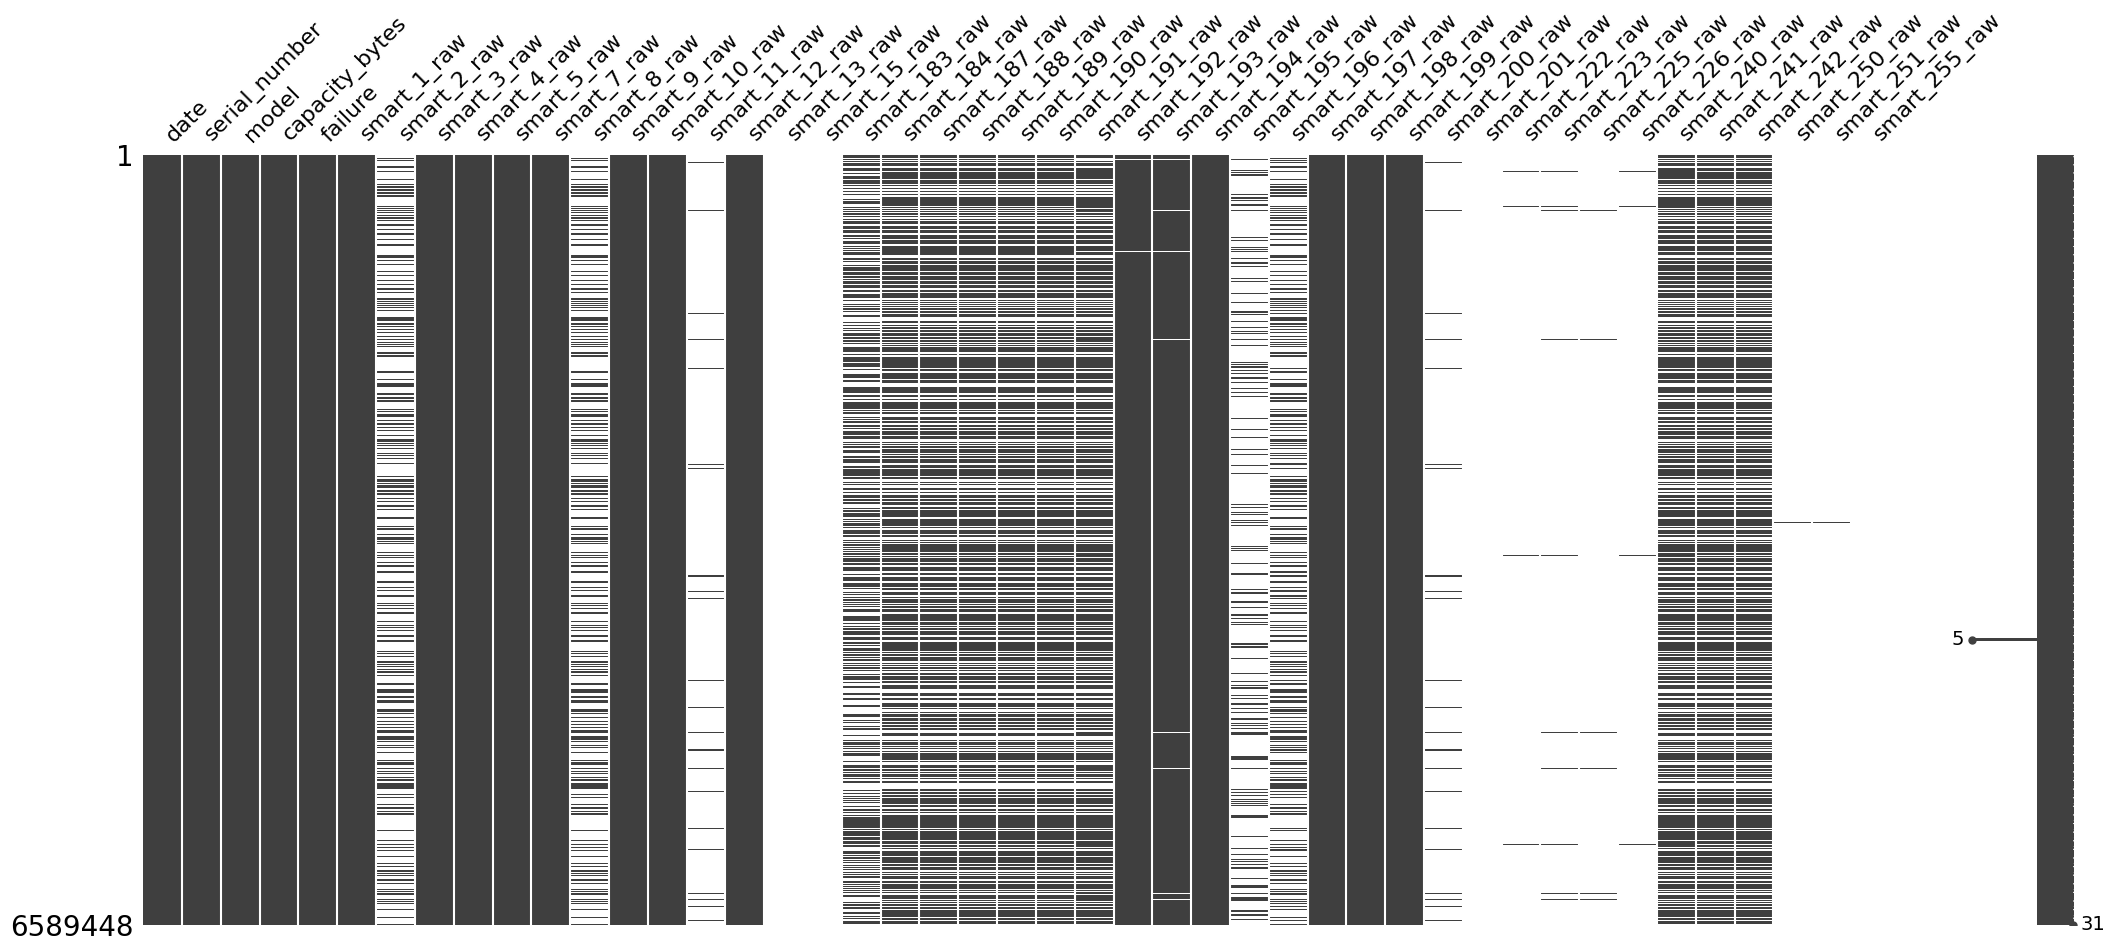

In [17]:
msno.matrix(cleaned_df)

plt.show()

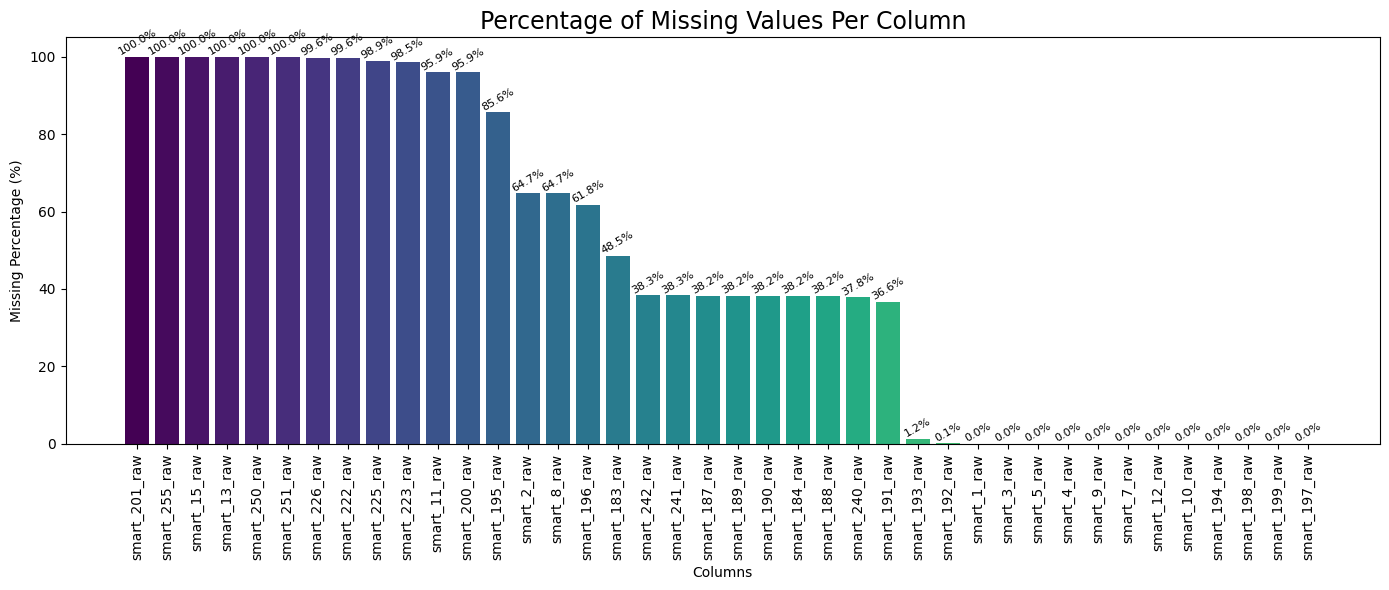

In [18]:
missing_percent = (cleaned_df.isna().sum() / len(cleaned_df)) * 100

missing_percent = missing_percent[missing_percent > 0]

colors = plt.cm.viridis(
    np.linspace(0, 1, len(missing_percent))
)

missing_percent = missing_percent.sort_values(ascending=False)

plt.figure(figsize=(14,6))

bars = plt.bar(missing_percent.index, missing_percent.values, color=colors)

for bar in bars:
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=30
    )

plt.xticks(rotation=90)
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Columns')
plt.title('Percentage of Missing Values Per Column', fontsize=17)

plt.tight_layout()
plt.show()

In [19]:
cleaned_df['smart_201_raw'].isna().sum()

np.int64(6589448)

In [20]:
def remove_highly_missing_columns(df, threshold=100):
    missing_percent = (df.isna().sum() / len(df)) * 100
    cols_to_drop = missing_percent[missing_percent >= threshold].index
    df = df.drop(columns=cols_to_drop)
    return df

In [21]:
print('shape before:', cleaned_df.shape)
cleaned_df1 = remove_highly_missing_columns(cleaned_df)
print('shape after:', cleaned_df1.shape)

shape before: (6589448, 45)
shape after: (6589448, 41)


### Removing rows with missing columns 

In [22]:
cleaned_df[['date', 'serial_number', 'model', 'capacity_bytes', 'failure']].isna().sum()

date              0
serial_number     0
model             0
capacity_bytes    0
failure           0
dtype: int64

In [23]:
def remove_missing_value_rows(df, columns=['date', 'serial_number', 'model', 'capacity_bytes', 'failure']):
    initial_count = len(df)
    df = df.dropna(subset=columns)
    final_count = len(df)
    print(f'Removed {initial_count - final_count} rows with missing values in columns: {columns}')
    return df

In [25]:
cleaned_df2 = remove_missing_value_rows(cleaned_df1)

Removed 0 rows with missing values in columns: ['date', 'serial_number', 'model', 'capacity_bytes', 'failure']


### Removing duplicated rows

In [26]:
def remove_duplicates(df):
    initial_count = len(df)
    df = df.drop_duplicates()
    final_count = len(df)
    print(f'Removed {initial_count - final_count} duplicate rows.')
    return df

In [27]:
cleaned_df3 = remove_duplicates(cleaned_df2)

Removed 0 duplicate rows.


### Dealing with missing values

In [28]:
def filling_missing_values(df, keyword='smart'):
    for col in df.columns:
        if keyword.lower() in col.lower():
            df[col] = df[col].fillna(0)
    return df

In [29]:
cleaned_df4 = filling_missing_values(cleaned_df3)

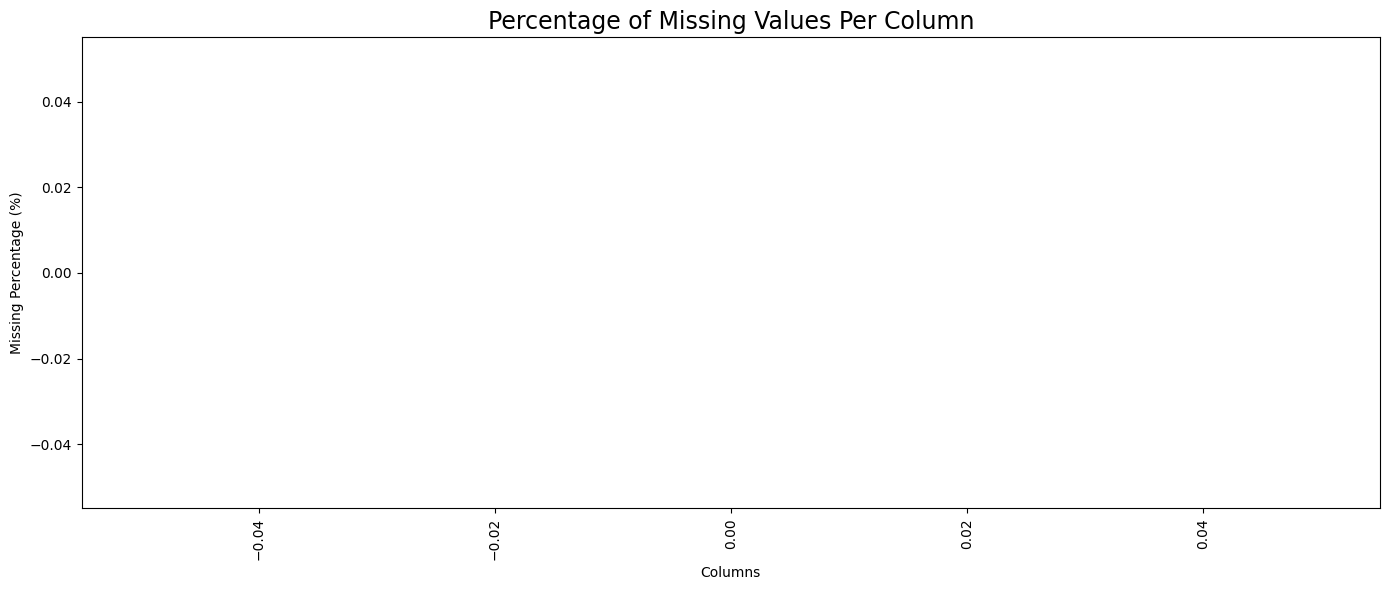

In [30]:
missing_percent = (cleaned_df4.isna().sum() / len(cleaned_df4)) * 100

missing_percent = missing_percent[missing_percent > 0]

colors = plt.cm.viridis(
    np.linspace(0, 1, len(missing_percent))
)

missing_percent = missing_percent.sort_values(ascending=False)

plt.figure(figsize=(14,6))

bars = plt.bar(missing_percent.index, missing_percent.values, color=colors)

for bar in bars:
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=30
    )

plt.xticks(rotation=90)
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Columns')
plt.title('Percentage of Missing Values Per Column', fontsize=17)

plt.tight_layout()
plt.show()

###  Exporting pickled dataset

In [31]:
print(f'finale shape: {cleaned_df4.shape}')

finale shape: (6589448, 41)


In [33]:
dir = 'data'

cleaned_df4.to_pickle(f"{dir}/train_data.pkl")

## Q3 - 2017 S.M.A.R.T Data

In [34]:
test_path = 'D:/stochastic/data/data_Q3_2017'
test_df = load__data(test_path)

### Initial Inspection

In [35]:
test_df.head()

,date,serial_number,model,capacity_bytes,failure,smart_1_raw,smart_2_raw,smart_3_raw,smart_4_raw,smart_5_raw,...,smart_225_raw,smart_226_raw,smart_240_raw,smart_241_raw,smart_242_raw,smart_250_raw,smart_251_raw,smart_252_raw,smart_254_raw,smart_255_raw
0,2017-07-01,MJ0351YNG9Z0XA,Hitachi HDS5C3030ALA630,3000592982016,0,0.0,107.0,554.0,16.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2017-07-01,MJ0351YNG9WJSA,Hitachi HDS5C3030ALA630,3000592982016,0,0.0,104.0,555.0,21.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2017-07-01,PL1321LAG34XWH,Hitachi HDS5C4040ALE630,4000787030016,0,0.0,101.0,560.0,32.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2017-07-01,MJ0351YNGABYAA,Hitachi HDS5C3030ALA630,3000592982016,0,0.0,104.0,507.0,17.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2017-07-01,PL2331LAHDBJPJ,HGST HMS5C4040BLE640,4000787030016,0,0.0,104.0,538.0,10.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
test_df.info(memory_usage='deep')

<class 'pandas.DataFrame'>
RangeIndex: 8004840 entries, 0 to 8004839
Data columns (total 50 columns):
 #   Column          Dtype  
---  ------          -----  
 0   date            str    
 1   serial_number   str    
 2   model           str    
 3   capacity_bytes  int64  
 4   failure         int64  
 5   smart_1_raw     float64
 6   smart_2_raw     float64
 7   smart_3_raw     float64
 8   smart_4_raw     float64
 9   smart_5_raw     float64
 10  smart_7_raw     float64
 11  smart_8_raw     float64
 12  smart_9_raw     float64
 13  smart_10_raw    float64
 14  smart_11_raw    float64
 15  smart_12_raw    float64
 16  smart_13_raw    float64
 17  smart_15_raw    float64
 18  smart_22_raw    float64
 19  smart_183_raw   float64
 20  smart_184_raw   float64
 21  smart_187_raw   float64
 22  smart_188_raw   float64
 23  smart_189_raw   float64
 24  smart_190_raw   float64
 25  smart_191_raw   float64
 26  smart_192_raw   float64
 27  smart_193_raw   float64
 28  smart_194_raw   float64

In [37]:
test_df.describe()

,capacity_bytes,failure,smart_1_raw,smart_2_raw,smart_3_raw,smart_4_raw,smart_5_raw,smart_7_raw,smart_8_raw,smart_9_raw,...,smart_225_raw,smart_226_raw,smart_240_raw,smart_241_raw,smart_242_raw,smart_250_raw,smart_251_raw,smart_252_raw,smart_254_raw,smart_255_raw
count,8.004840e+06,8.004840e+06,8.003835e+06,2.590777e+06,8.003835e+06,8.003835e+06,8.003835e+06,8.003835e+06,2.590777e+06,8.003835e+06,...,7.115700e+04,54955.000000,5.352322e+06,5.290123e+06,5.290123e+06,8.280000e+02,828.000000,828.0,9187.0,0.0
mean,4.926330e+12,4.897037e-05,8.043386e+07,9.719482e+01,2.179231e+02,1.057902e+01,1.976972e+00,1.374234e+10,3.979828e+01,1.607039e+04,...,3.951364e+05,291.479319,5.145273e+12,2.962635e+10,8.248539e+10,2.011833e+07,91569.388889,0.0,0.0,NaN
std,1.835453e+12,6.997713e-03,8.131926e+07,2.257484e+01,8.320420e+02,8.653146e+01,1.708930e+02,1.785684e+12,9.173613e+00,1.105073e+04,...,3.593527e+05,51.772618,3.061534e+13,1.145182e+10,4.081846e+11,1.045261e+07,29580.999064,0.0,0.0,NaN
min,-1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,3.368700e+04,237.000000,0.000000e+00,0.000000e+00,4.224000e+03,3.991800e+04,260.000000,0.0,0.0,NaN
25%,4.000787e+12,0.000000e+00,0.000000e+00,1.000000e+02,0.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,4.200000e+01,5.961000e+03,...,1.055970e+05,257.000000,6.486000e+03,2.342673e+10,3.152027e+10,1.098537e+07,79059.750000,0.0,0.0,NaN
50%,4.000787e+12,0.000000e+00,5.897492e+07,1.020000e+02,0.000000e+00,6.000000e+00,0.000000e+00,4.221708e+08,4.200000e+01,1.451400e+04,...,2.368150e+05,264.000000,1.426300e+04,3.031269e+10,4.130214e+10,2.168335e+07,100631.000000,0.0,0.0,NaN
75%,6.001175e+12,0.000000e+00,1.513304e+08,1.040000e+02,0.000000e+00,1.000000e+01,0.000000e+00,7.951862e+08,4.200000e+01,2.520000e+04,...,6.015560e+05,309.000000,2.177200e+04,3.790074e+10,7.626014e+10,2.910083e+07,110995.250000,0.0,0.0,NaN
max,1.200014e+13,1.000000e+00,9.502786e+08,7.130000e+02,9.766000e+03,7.977000e+03,4.051200e+04,2.814717e+14,5.100000e+01,6.785200e+04,...,1.981155e+06,422.000000,2.814707e+14,1.142979e+11,3.234107e+13,3.807949e+07,135053.000000,0.0,0.0,NaN


### Detecting and removing constant columns

In [38]:
test_indicators, test_constant_columns, test_informative_columns, test_cleaned_df = remove_constant_columns(test_df)

In [39]:
print('shape before removing constant columns:', test_df.shape)
print('shape after removing constant columns:', test_cleaned_df.shape)

shape before removing constant columns: (8004840, 50)
shape after removing constant columns: (8004840, 46)


In [41]:
test_indicators

,distinct_values,min_value,max_value
date,92,2017-07-01,2017-09-30
serial_number,95188,13H2B97AS,ZCH068MS
model,52,HGST HDS5C4040ALE630,WDC WD60EFRX
capacity_bytes,16,-1,12000138625024
failure,2,0,1
smart_1_raw,4875917,0.0,950278612.0
smart_2_raw,85,0.0,713.0
smart_3_raw,1473,0.0,9766.0
smart_4_raw,2425,1.0,7977.0
smart_5_raw,536,0.0,40512.0


In [42]:
test_constant_columns

['smart_220_raw', 'smart_224_raw', 'smart_252_raw', 'smart_254_raw']

In [43]:
test_informative_columns

Index(['capacity_bytes', 'date', 'failure', 'model', 'serial_number',
       'smart_10_raw', 'smart_11_raw', 'smart_12_raw', 'smart_13_raw',
       'smart_15_raw', 'smart_183_raw', 'smart_184_raw', 'smart_187_raw',
       'smart_188_raw', 'smart_189_raw', 'smart_190_raw', 'smart_191_raw',
       'smart_192_raw', 'smart_193_raw', 'smart_194_raw', 'smart_195_raw',
       'smart_196_raw', 'smart_197_raw', 'smart_198_raw', 'smart_199_raw',
       'smart_1_raw', 'smart_200_raw', 'smart_201_raw', 'smart_222_raw',
       'smart_223_raw', 'smart_225_raw', 'smart_226_raw', 'smart_22_raw',
       'smart_240_raw', 'smart_241_raw', 'smart_242_raw', 'smart_250_raw',
       'smart_251_raw', 'smart_255_raw', 'smart_2_raw', 'smart_3_raw',
       'smart_4_raw', 'smart_5_raw', 'smart_7_raw', 'smart_8_raw',
       'smart_9_raw'],
      dtype='str')

### Removing Columns with null values

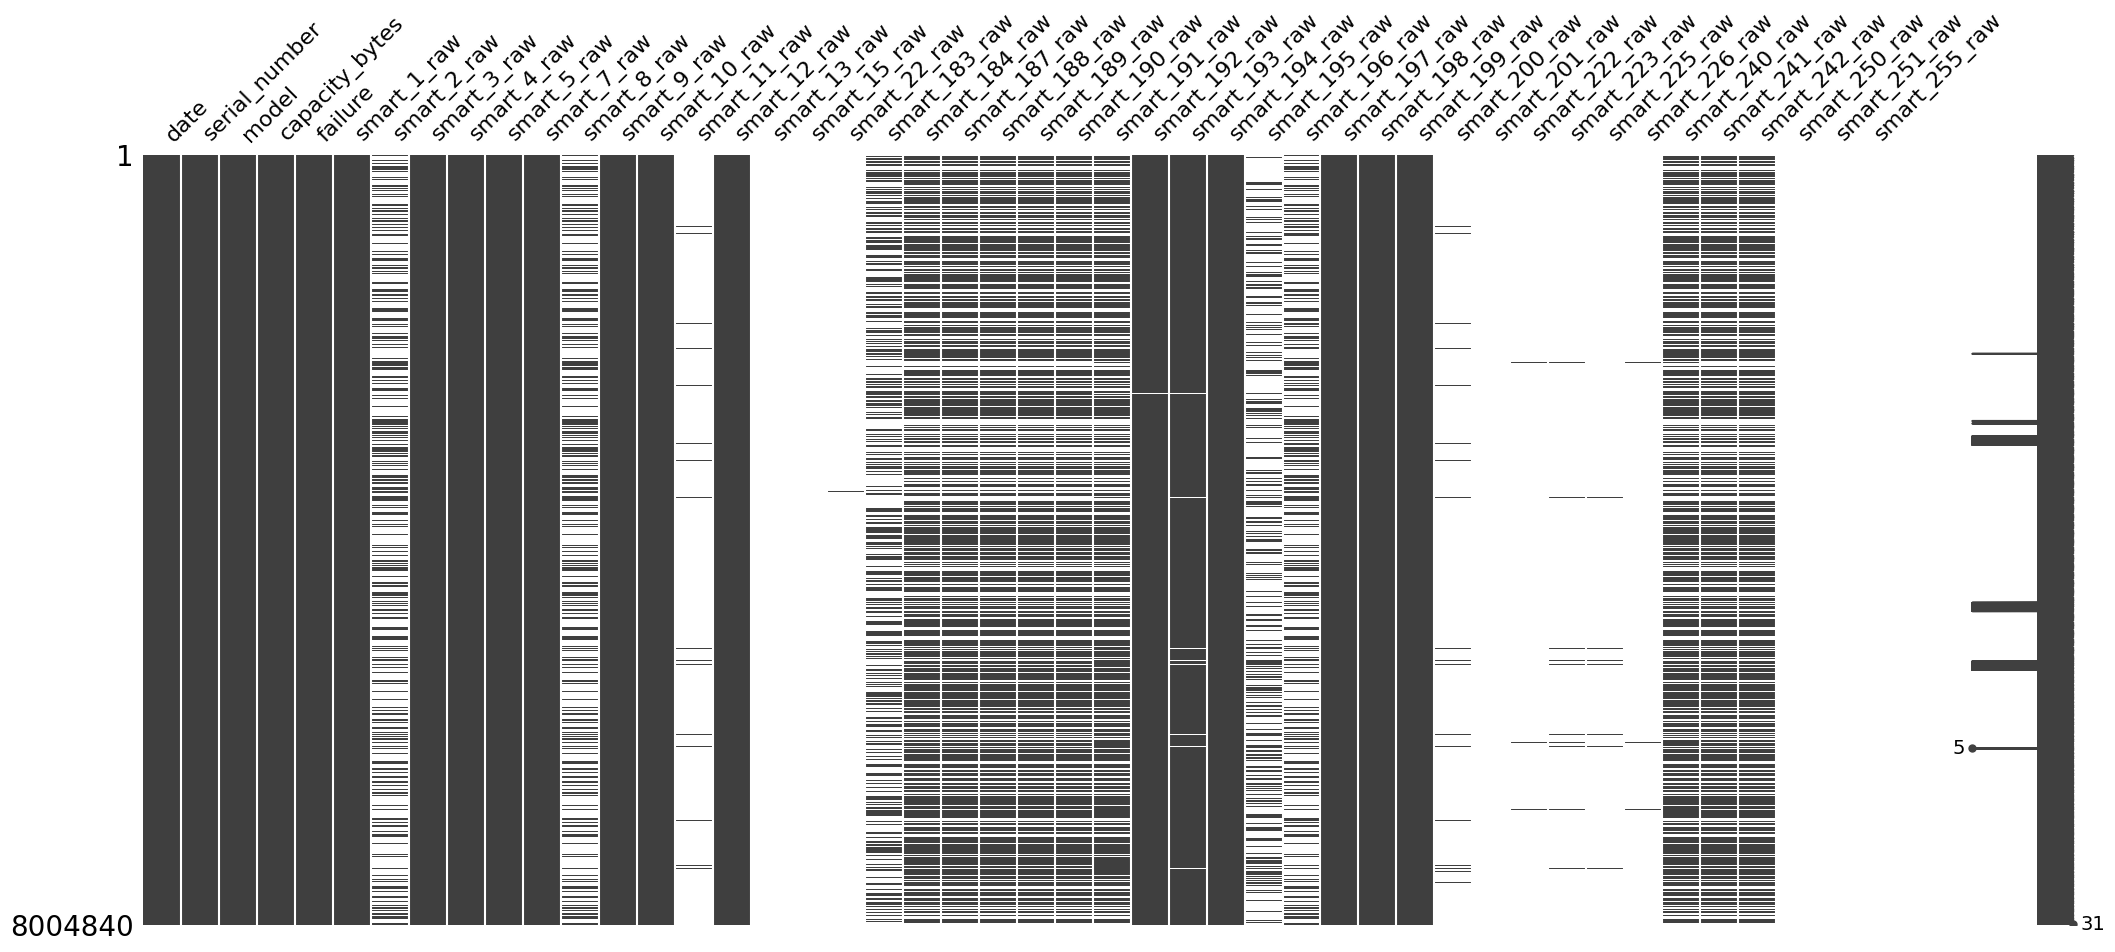

In [45]:
msno.matrix(test_cleaned_df)

plt.show()

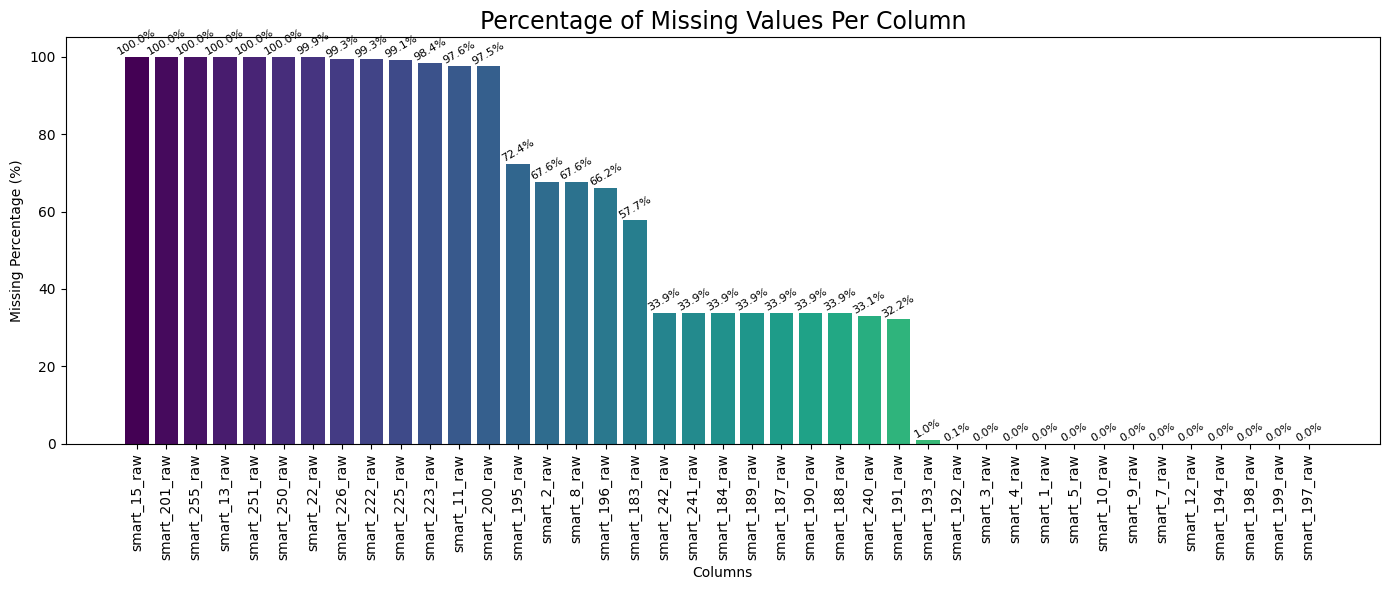

In [46]:
missing_percent = (test_cleaned_df.isna().sum() / len(test_cleaned_df)) * 100

missing_percent = missing_percent[missing_percent > 0]

colors = plt.cm.viridis(
    np.linspace(0, 1, len(missing_percent))
)

missing_percent = missing_percent.sort_values(ascending=False)

plt.figure(figsize=(14,6))

bars = plt.bar(missing_percent.index, missing_percent.values, color=colors)

for bar in bars:
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=30
    )

plt.xticks(rotation=90)
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Columns')
plt.title('Percentage of Missing Values Per Column', fontsize=17)

plt.tight_layout()
plt.show()

In [47]:
print('shape before:', test_cleaned_df.shape)
test_cleaned_df1 = remove_highly_missing_columns(test_cleaned_df)
print('shape after:', test_cleaned_df1.shape)

shape before: (8004840, 46)
shape after: (8004840, 42)


### Removing rows with missing columns 

In [48]:
test_cleaned_df1[['date', 'serial_number', 'model', 'capacity_bytes', 'failure']].isna().sum()

date              0
serial_number     0
model             0
capacity_bytes    0
failure           0
dtype: int64

In [49]:
test_cleaned_df2 = remove_missing_value_rows(test_cleaned_df1)

Removed 0 rows with missing values in columns: ['date', 'serial_number', 'model', 'capacity_bytes', 'failure']


### Removing duplicated rows

In [50]:
test_cleaned_df3 = remove_duplicates(test_cleaned_df2)

Removed 0 duplicate rows.


### Dealing with missing values

In [51]:
test_cleaned_df4 = filling_missing_values(test_cleaned_df3)

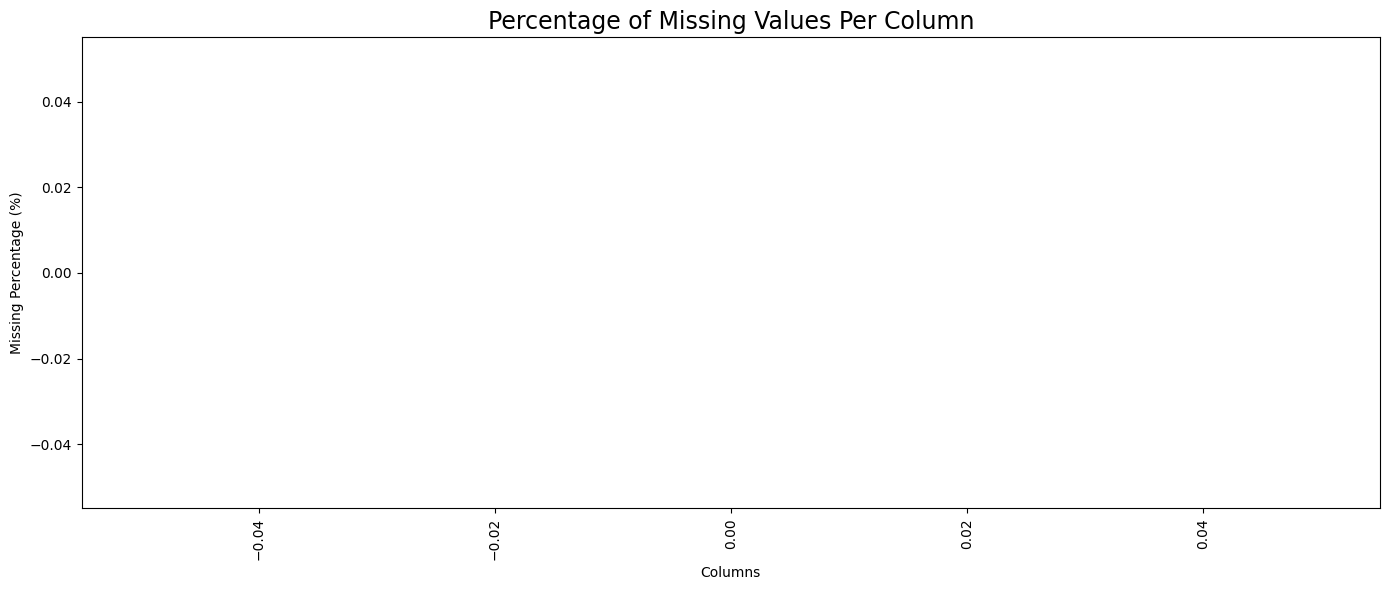

In [52]:
missing_percent = (test_cleaned_df4.isna().sum() / len(test_cleaned_df4)) * 100

missing_percent = missing_percent[missing_percent > 0]

colors = plt.cm.viridis(
    np.linspace(0, 1, len(missing_percent))
)

missing_percent = missing_percent.sort_values(ascending=False)

plt.figure(figsize=(14,6))

bars = plt.bar(missing_percent.index, missing_percent.values, color=colors)

for bar in bars:
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=30
    )

plt.xticks(rotation=90)
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Columns')
plt.title('Percentage of Missing Values Per Column', fontsize=17)

plt.tight_layout()
plt.show()

###  Exporting pickled dataset

In [53]:
print(f'finale shape: {test_cleaned_df4.shape}')

finale shape: (8004840, 42)


In [54]:
dir = 'data'

test_cleaned_df4.to_pickle(f"{dir}/test_data.pkl")